# Notebook 01 — Instruments Pricing & Sensitivities

This notebook prices all four instrument families and computes their key risk sensitivities.

| Instrument | Model | Key sensitivity |
|---|---|---|
| **IRS** | Flat discount curve | DV01 (dollar duration) |
| **FX Forward** | Cost-of-carry | Delta (FX rate sensitivity) |
| **FX Option** | Garman-Kohlhagen | Delta, Vega |
| **CDS** | Reduced-form / intensity | CS01 (credit spread sensitivity) |
| **Equity Option** | Black-Scholes | Delta, Gamma, Vega, Theta |

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

from ccr.instruments import IRSwap, FXForward, FXOption, CDS, EquityOption

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

print('Setup complete.')

Setup complete.


## 1. Interest Rate Swap — MtM and DV01

A **payer IRS** (pays fixed, receives floating) has positive MtM when market rates rise above the fixed rate K. The DV01 quantifies the loss per 1 bp parallel shift — it grows with maturity (more cash flows are discounted).

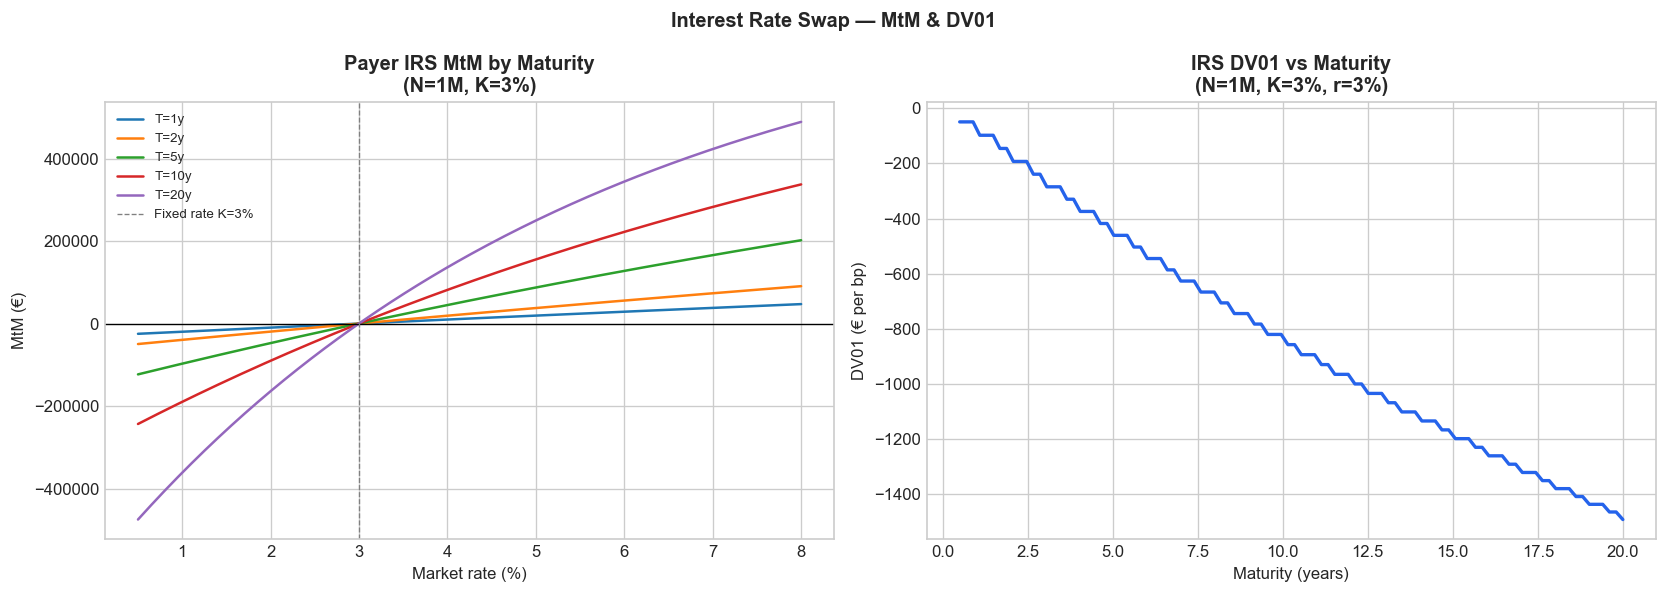


Maturity          MtM @2%      MtM @3%      MtM @5%         DV01
------------------------------------------------------------
1                  -9,851            0       19,265          -98
2                 -19,507            0       37,591         -193
5                 -47,344            0       87,378         -461
10                -90,182            0      155,429         -857
20               -164,017            0      249,701       -1,491


In [2]:
rates = np.linspace(0.005, 0.08, 200)
maturities = [1, 2, 5, 10, 20]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# MtM by rate for different maturities
for mat in maturities:
    swap = IRSwap(notional=1_000_000, fixed_rate=0.03, maturity=mat, position='payer')
    mtms = [swap.mtm(r) for r in rates]
    axes[0].plot(rates * 100, mtms, lw=1.5, label=f'T={mat}y')

axes[0].axhline(0, color='black', lw=0.8)
axes[0].axvline(3.0, color='grey', ls='--', lw=0.8, label='Fixed rate K=3%')
axes[0].set_xlabel('Market rate (%)')
axes[0].set_ylabel('MtM (€)')
axes[0].set_title('Payer IRS MtM by Maturity\n(N=1M, K=3%)', fontweight='bold')
axes[0].legend(fontsize=8)

# DV01 by maturity
mats_range = np.linspace(0.5, 20, 100)
dv01s = [IRSwap(notional=1_000_000, fixed_rate=0.03, maturity=m).dv01(0.03) for m in mats_range]
axes[1].plot(mats_range, dv01s, color='#2563EB', lw=2)
axes[1].set_xlabel('Maturity (years)')
axes[1].set_ylabel('DV01 (€ per bp)')
axes[1].set_title('IRS DV01 vs Maturity\n(N=1M, K=3%, r=3%)', fontweight='bold')

plt.suptitle('Interest Rate Swap — MtM & DV01', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary table
print(f'\n{"Maturity":<12} {"MtM @2%":>12} {"MtM @3%":>12} {"MtM @5%":>12} {"DV01":>12}')
print('-' * 60)
for mat in [1, 2, 5, 10, 20]:
    swap = IRSwap(notional=1_000_000, fixed_rate=0.03, maturity=mat, position='payer')
    print(f'{mat:<12} {swap.mtm(0.02):>12,.0f} {swap.mtm(0.03):>12,.0f} {swap.mtm(0.05):>12,.0f} {swap.dv01(0.03):>12,.0f}')

## 2. FX Option — Greeks and Vol Surface

FX options are priced with **Garman-Kohlhagen** (1983) — the extension of Black-Scholes to FX, accounting for both domestic and foreign interest rates.

Key intuition:
- **Delta** of a call is close to 0 for deep OTM, ~0.5 ATM, ~1 deep ITM
- **Vega** peaks ATM — the volatility sensitivity is highest when there is maximum time-value uncertainty

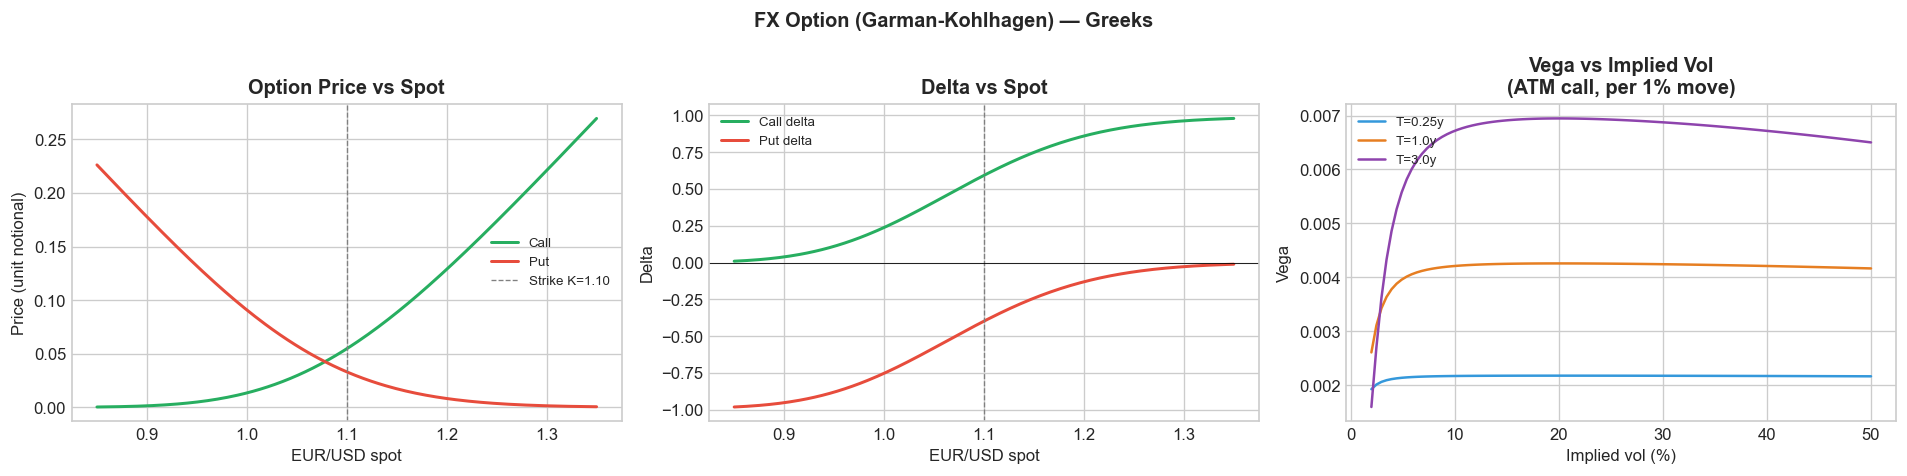

In [3]:
S_range = np.linspace(0.85, 1.35, 200)  # EUR/USD spot
K, rd, rf, T, sig = 1.10, 0.03, 0.01, 1.0, 0.10

call = FXOption(notional_foreign=1.0, strike=K, maturity=T, option_type='call', sigma=sig)
put  = FXOption(notional_foreign=1.0, strike=K, maturity=T, option_type='put',  sigma=sig)

call_prices = [call.price(s, rd, rf) for s in S_range]
put_prices  = [put.price(s, rd, rf)  for s in S_range]
call_deltas = [FXOption(1.0, K, T, 'call', sigma=sig).delta(s, rd, rf) for s in S_range]
put_deltas  = [FXOption(1.0, K, T, 'put',  sigma=sig).delta(s, rd, rf) for s in S_range]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(S_range, call_prices, color='#27ae60', lw=1.8, label='Call')
axes[0].plot(S_range, put_prices,  color='#e74c3c', lw=1.8, label='Put')
axes[0].axvline(K, color='grey', ls='--', lw=0.8, label='Strike K=1.10')
axes[0].set_title('Option Price vs Spot', fontweight='bold')
axes[0].set_xlabel('EUR/USD spot'); axes[0].set_ylabel('Price (unit notional)')
axes[0].legend(fontsize=8)

axes[1].plot(S_range, call_deltas, color='#27ae60', lw=1.8, label='Call delta')
axes[1].plot(S_range, put_deltas,  color='#e74c3c', lw=1.8, label='Put delta')
axes[1].axvline(K, color='grey', ls='--', lw=0.8)
axes[1].axhline(0, color='black', lw=0.5)
axes[1].set_title('Delta vs Spot', fontweight='bold')
axes[1].set_xlabel('EUR/USD spot'); axes[1].set_ylabel('Delta')
axes[1].legend(fontsize=8)

# Vol sensitivity (Vega) by maturity
vols = np.linspace(0.02, 0.50, 100)
for T_opt, color in [(0.25, '#3498db'), (1.0, '#e67e22'), (3.0, '#8e44ad')]:
    vegas = [FXOption(1.0, K, T_opt, 'call', sigma=v).vega(K, rd, rf) for v in vols]
    axes[2].plot(vols * 100, vegas, lw=1.5, color=color, label=f'T={T_opt}y')

axes[2].set_title('Vega vs Implied Vol\n(ATM call, per 1% move)', fontweight='bold')
axes[2].set_xlabel('Implied vol (%)')
axes[2].set_ylabel('Vega')
axes[2].legend(fontsize=8)

plt.suptitle('FX Option (Garman-Kohlhagen) — Greeks', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. CDS — Spread dynamics and CS01

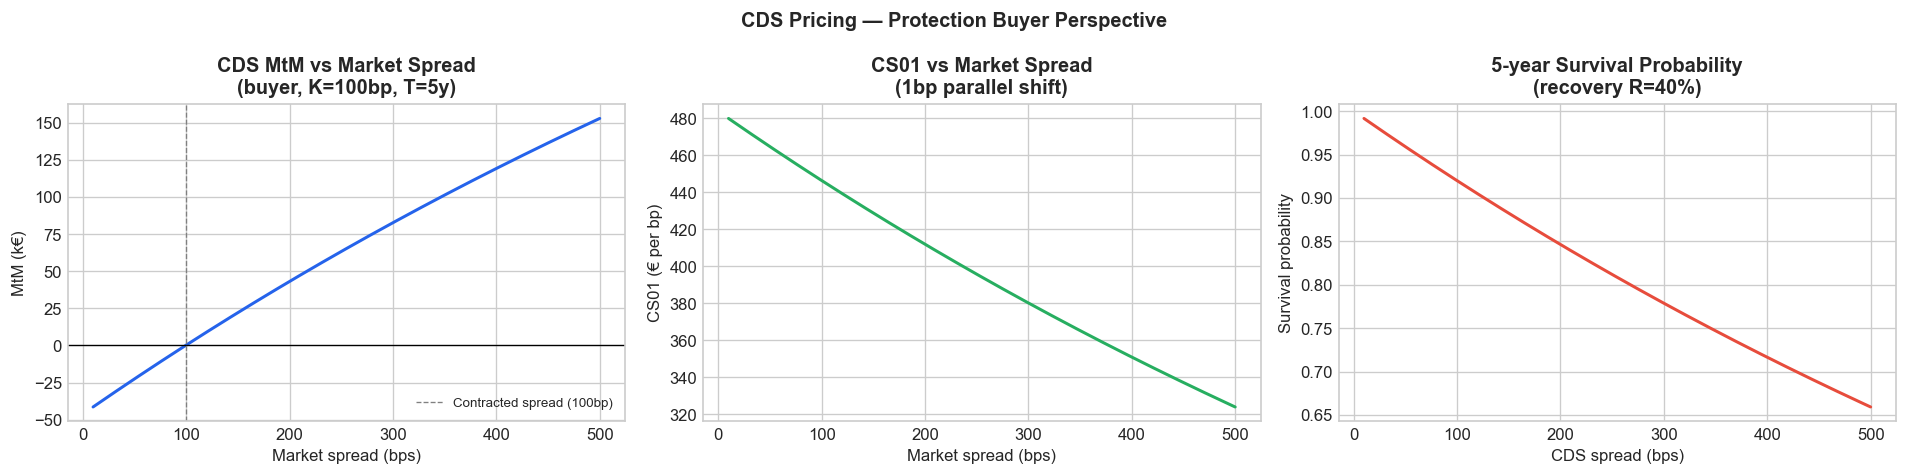

In [4]:
spreads_mkt = np.linspace(10, 500, 200) / 10_000  # 10bp to 500bp
cds = CDS(notional=1_000_000, spread=100/10_000, maturity=5.0, recovery=0.40,
          position='protection_buyer')

mtms   = [cds.mtm(0.03, s) for s in spreads_mkt]
cs01s  = [cds.cs01(0.03, s) for s in spreads_mkt]
surv5y = [cds.survival_prob(5.0, s) for s in spreads_mkt]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(spreads_mkt * 10_000, [m/1000 for m in mtms], color='#2563EB', lw=1.8)
axes[0].axhline(0, color='black', lw=0.8)
axes[0].axvline(100, color='grey', ls='--', lw=0.8, label='Contracted spread (100bp)')
axes[0].set_xlabel('Market spread (bps)'); axes[0].set_ylabel('MtM (k€)')
axes[0].set_title('CDS MtM vs Market Spread\n(buyer, K=100bp, T=5y)', fontweight='bold')
axes[0].legend(fontsize=8)

axes[1].plot(spreads_mkt * 10_000, cs01s, color='#27ae60', lw=1.8)
axes[1].set_xlabel('Market spread (bps)'); axes[1].set_ylabel('CS01 (€ per bp)')
axes[1].set_title('CS01 vs Market Spread\n(1bp parallel shift)', fontweight='bold')

axes[2].plot(spreads_mkt * 10_000, surv5y, color='#e74c3c', lw=1.8)
axes[2].set_xlabel('CDS spread (bps)'); axes[2].set_ylabel('Survival probability')
axes[2].set_title('5-year Survival Probability\n(recovery R=40%)', fontweight='bold')

plt.suptitle('CDS Pricing — Protection Buyer Perspective', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Equity Option — Greeks dashboard

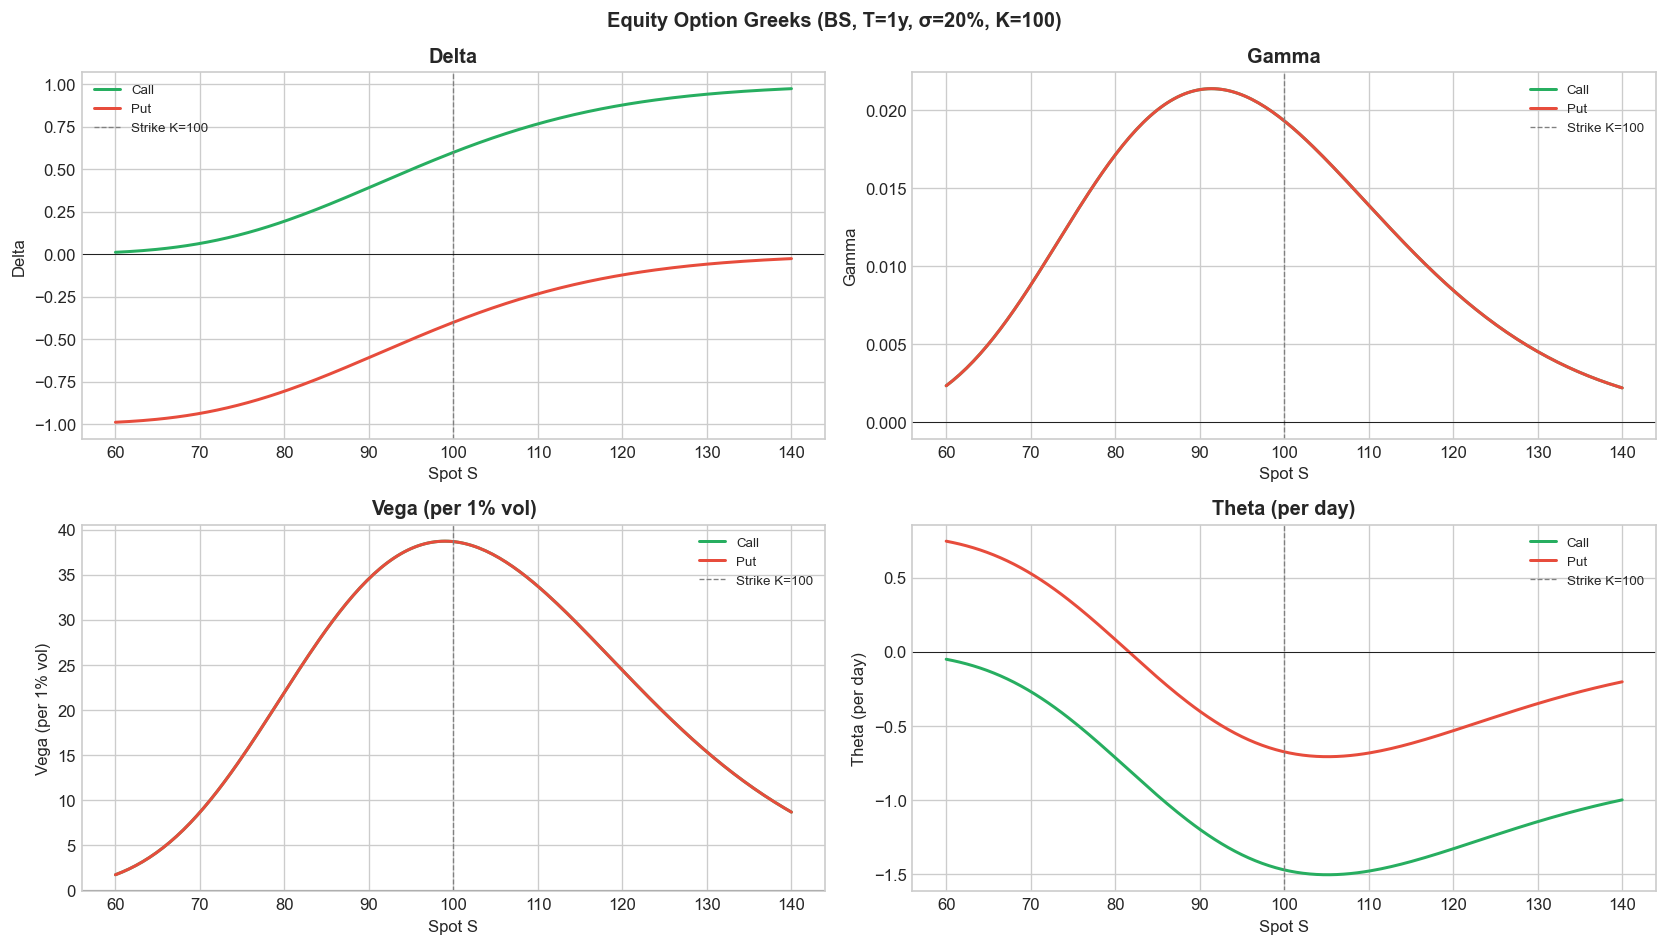


ATM Call Greeks (S=K=100, T=1y, σ=20%)
  price   :     9.4134
  delta   :     0.5987
  gamma   :     0.0193
  vega    :    38.6668
  theta   :    -1.4741
  rho     :    50.4572


In [5]:
S_range = np.linspace(60, 140, 200)
K_eq, T_eq, sig_eq, r_eq = 100.0, 1.0, 0.20, 0.03

def greeks_profile(S_arr, K, T, sig, r, opt_type):
    results = {'delta': [], 'gamma': [], 'vega': [], 'theta': []}
    for s in S_arr:
        opt = EquityOption(spot=s, strike=K, maturity=T, sigma=sig, rate=r, option_type=opt_type)
        results['delta'].append(opt.delta())
        results['gamma'].append(opt.gamma())
        results['vega'].append(opt.vega())
        results['theta'].append(opt.theta())
    return results

g_call = greeks_profile(S_range, K_eq, T_eq, sig_eq, r_eq, 'call')
g_put  = greeks_profile(S_range, K_eq, T_eq, sig_eq, r_eq, 'put')

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, key, ylabel in zip(axes.flat,
    ['delta', 'gamma', 'vega', 'theta'],
    ['Delta', 'Gamma', 'Vega (per 1% vol)', 'Theta (per day)']):

    ax.plot(S_range, g_call[key], color='#27ae60', lw=1.8, label='Call')
    ax.plot(S_range, g_put[key],  color='#e74c3c', lw=1.8, label='Put')
    ax.axvline(K_eq, color='grey', ls='--', lw=0.8, label='Strike K=100')
    ax.axhline(0, color='black', lw=0.5)
    ax.set_title(ylabel, fontweight='bold')
    ax.set_xlabel('Spot S')
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=8)

plt.suptitle('Equity Option Greeks (BS, T=1y, σ=20%, K=100)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# ATM summary
atm = EquityOption(spot=100, strike=100, maturity=1.0, sigma=0.20, rate=0.03)
g = atm.greeks()
print('\nATM Call Greeks (S=K=100, T=1y, σ=20%)')
for k, v in g.items():
    print(f'  {k:<8}: {v:>10.4f}')